In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.kernel_ridge import KernelRidge

# Exercise 2.1

Text(0, 0.5, 'y')

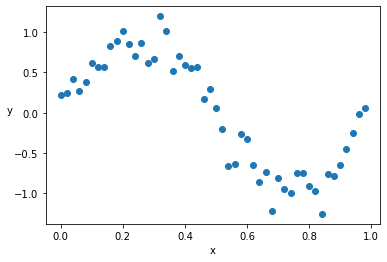

In [2]:
# Part 1
## import data
sin_df = pd.read_csv('data_sin.csv')

## create scatter plot of x versus y 
x = sin_df['x'].to_numpy()
y = sin_df['y'].to_numpy()
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y',rotation=0)

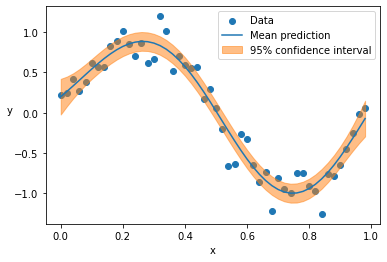

In [3]:
## Part 2
# choose kernel (this describes the expected correlation between observations at different points x)
X = x[:,None] # reshape x for processing
kernel = RBF(length_scale=1., length_scale_bounds=(1e-2, 1e2))

## fit Gaussian process to the data
sigma = 0.2
gaussian_process = GaussianProcessRegressor(kernel=kernel,alpha=sigma**2)
gaussian_process.fit(X, y)

## get the mean and standard deviation of the fitted Gaussian process at x
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)

## scatter plot of input data
plt.scatter(x,y,label='Data')

## add to the plot the mean and confidence interval of fitted Gaussian process
plt.plot(x, mean_prediction, label="Mean prediction")
plt.fill_between(
    x,
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    color="tab:orange",
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.xlabel('x')
plt.ylabel('y',rotation=0)

plt.legend()

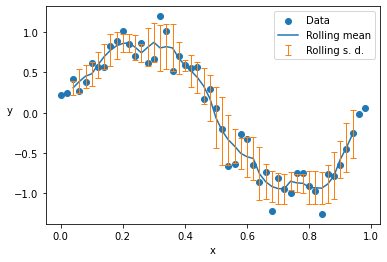

In [4]:
# Part 3
## get rolling mean and standard deviation
sin_roll = sin_df.rolling(5,on="x",center=True)
sin_roll_mean = sin_roll.mean()

x_mean = sin_roll_mean['x'].to_numpy()
y_mean = sin_roll_mean['y'].to_numpy()
yerr = sin_roll["y"].std().to_numpy()

## plot data, mean, and error bars
plt.scatter(x,y,label='Data')
plt.plot(x_mean,y_mean,label='Rolling mean')
plt.errorbar(x_mean,y_mean,yerr=yerr,lw=0,elinewidth=1,capsize=3,label='Rolling s. d.')
plt.xlabel('x')
plt.ylabel('y',rotation=0)
plt.legend()

# Exercise 2.2

In [5]:
# Part 1
## Import the data and convert first_obs to a date and class to a category
asteroid_df = pd.read_csv("data_astroids.csv")
asteroid_df["first_obs"] = asteroid_df["first_obs"].astype("datetime64[ns]")
asteroid_df["class"] = asteroid_df["class"].astype("category")

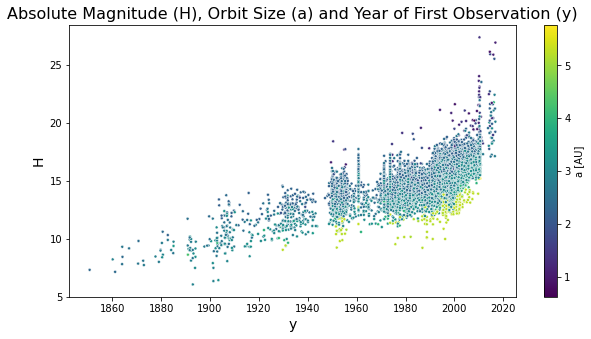

In [6]:
# Part 2
## make chart showing the relation between the variables H, first_obs, and a
fig = plt.figure(figsize = (10,5))
norm = plt.Normalize(asteroid_df["a"].min(), asteroid_df["a"].max())
sm = cm.ScalarMappable(cmap = "viridis", norm = norm)
sns.scatterplot(data = asteroid_df, x = "first_obs", y = "H", hue = "a", \
                     palette = "viridis", marker = ".", legend = None)

plt.title("Absolute Magnitude (H), Orbit Size (a) and Year of First Observation (y)" , fontsize = 16)
plt.xlabel("y", fontsize = 14)
plt.ylabel("H", fontsize = 14)
plt.colorbar(sm, norm = norm, label = "a [AU]");
plt.show()

Text(0.5, 0, 'Year of Detection')

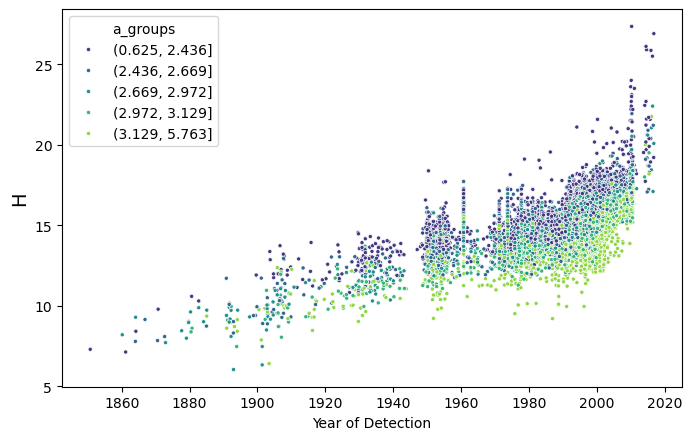

In [7]:
# Part 3
## cut the data into groups according to their 'a' value
axis_groups = pd.qcut(asteroid_df["a"], 5)
asteroid_df["a_groups"] = axis_groups

## scatter plot to show relation between H and first_obs for each a-group
fig, ax = plt.subplots(1,1,figsize=(8,5),dpi=100)

sns.scatterplot(asteroid_df,x="first_obs",y="H",hue="a_groups",palette="viridis",marker=".",ax=ax)

ax.set_ylabel("H", fontsize = 14)
ax.set_xlabel("Year of Detection", fontsize = 10)

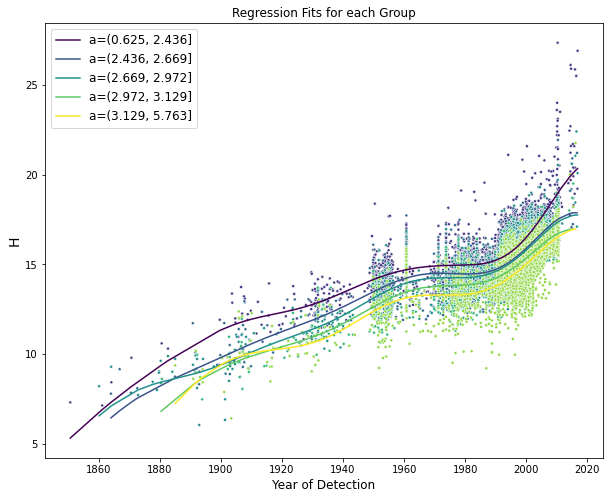

In [8]:
# Part 4
## perform linear regression on each group
asteroid_groupby_a = asteroid_df.groupby(axis_groups, observed = False)[["first_obs", "H", "a_groups"]]

predictors = []
for group in asteroid_groupby_a:
    sorted_group = group[1].sort_values(by="first_obs")
    ts = sorted_group["first_obs"].values.astype(np.float64)/1.0e18
    Hs = sorted_group["H"].values.astype(np.float64)

    krr = KernelRidge(alpha = 1.0, kernel="rbf")
    krr.fit(ts[:,None], Hs)
    predictors.append(krr)

fig, ax = plt.subplots(1, 1, figsize = (10, 8))

for i,group in enumerate(asteroid_groupby_a):
    sns.scatterplot(group[1], x = "first_obs", y = "H", hue = "a_groups", \
                    palette = "viridis", marker = ".", ax = ax, legend = None)
    sorted_group = group[1].sort_values(by="first_obs")
    ts = sorted_group["first_obs"].values.astype(np.float64)/1.0e18
    
    predicted = predictors[i].predict(ts.reshape(-1, 1)).ravel()
    ts_date = (1e18*ts).astype("datetime64[ns]")
    ax.plot(ts_date, predicted, color = cm.viridis(np.linspace(0.0, 1.0, 5))[i], label = "a="+str(group[0]))

plt.title("Regression Fits for each Group")
ax.set_ylabel("H", fontsize = 14)
ax.set_xlabel("Year of Detection", fontsize = 12)
ax.legend(fontsize = 12)

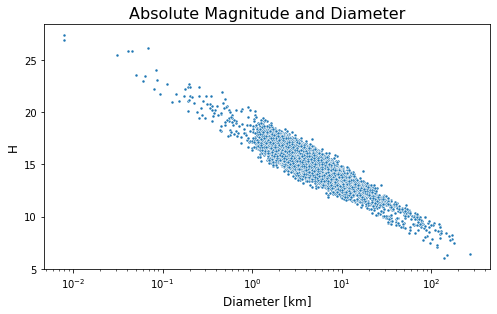

In [9]:
# Part 5
## plot absolute magnitude against diameter with a log scale for diameter
fig = plt.figure(figsize = (8, 4.5))
ax = sns.scatterplot(data = asteroid_df, x = "diameter", y = "H", \
                     marker = ".")

ax.set_xscale("log")
ax.set_title("Absolute Magnitude and Diameter", fontsize = 16)
ax.set_xlabel("Diameter [km]", fontsize = 12)
ax.set_ylabel("H", fontsize = 12)
plt.show()